Carga del dataset procesado y importación de librerías

In [1]:
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


DATA_PATH = Path("../data/processed/ag_news_processed.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()


(127600, 9)


,Class Index,Title,Description,category,text,clean_text,processed_text,original_word_count,processed_word_count
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...,wall st bears claw black reuter reuter short s...,21,17
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...,carlyle look commercial aerospace reuters reut...,36,23
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...,oil economy cloud stock outlook reuters reuter...,36,23
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...,iraq halt oil export main southern pipeline re...,36,28
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...,oil price soar time record pose new menace eco...,37,27


 Carga del dataset procesado

In [2]:
DATA_PATH = Path("../data/processed/ag_news_processed.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(127600, 9)


,Class Index,Title,Description,category,text,clean_text,processed_text,original_word_count,processed_word_count
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back into the black reuters...,wall st bears claw black reuter reuter short s...,21,17
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...,carlyle look commercial aerospace reuters reut...,36,23
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks outlook reuters r...,oil economy cloud stock outlook reuters reuter...,36,23
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...,iraq halt oil export main southern pipeline re...,36,28
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business,"Oil prices soar to all-time record, posing new...",oil prices soar to all time record posing new ...,oil price soar time record pose new menace eco...,37,27


Selección de variables

In [3]:
X = df["processed_text"]

y = df["category"]

print("Cantidad de textos:", X.shape[0])
print("Cantidad de etiquetas:", y.shape[0])

print("\nDistribución de clases:")
print(y.value_counts())

Cantidad de textos: 127600
Cantidad de etiquetas: 127600

Distribución de clases:
category
Business    31900
Sci/Tech    31900
Sports      31900
World       31900
Name: count, dtype: int64


División entrenamiento y prueba

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("\nDistribución entrenamiento:")
print(y_train.value_counts())

print("\nDistribución prueba:")
print(y_test.value_counts())

Entrenamiento: (102080,)
Prueba: (25520,)

Distribución entrenamiento:
category
Sci/Tech    25520
Sports      25520
World       25520
Business    25520
Name: count, dtype: int64

Distribución prueba:
category
Business    6380
Sports      6380
Sci/Tech    6380
World       6380
Name: count, dtype: int64


Vectorización TF-IDF

In [5]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Dimensión entrenamiento:", X_train_tfidf.shape)
print("Dimensión prueba:", X_test_tfidf.shape)

Dimensión entrenamiento: (102080, 5000)
Dimensión prueba: (25520, 5000)


Entrenamiento del modelo de Regresión Logística

In [6]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Generación de predicciones

In [7]:
y_pred = model.predict(X_test_tfidf)

y_pred[:10]

array(['Business', 'Sports', 'Sports', 'Business', 'Sports', 'Sci/Tech',
       'Sci/Tech', 'Sports', 'Business', 'World'], dtype=object)

Inspección del vocabulario TF-IDF

In [8]:
feature_names = tfidf.get_feature_names_out()

print("Cantidad de términos:")
print(len(feature_names))

print("\nPrimeros 50 términos:")
print(feature_names[:50])

Cantidad de términos:
5000

Primeros 50 términos:
['aa' 'aapl' 'aaron' 'abandon' 'abbas' 'abbey' 'abc' 'abduct' 'abdullah'
 'abidjan' 'ability' 'able' 'aboard' 'abroad' 'absence' 'abu' 'abuja'
 'abuse' 'ac' 'academic' 'academy' 'acc' 'accelerate' 'accept' 'access'
 'accident' 'accord' 'account' 'accounting' 'accusation' 'accuse' 'ace'
 'achieve' 'achievement' 'acknowledge' 'acquire' 'acquisition' 'acquit'
 'acrobat' 'act' 'action' 'activate' 'active' 'activist' 'activity'
 'actor' 'actually' 'ad' 'adam' 'adapter']


Evaluación del modelo

In [9]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

metrics = {
    "accuracy": accuracy,
    "precision_weighted": precision,
    "recall_weighted": recall,
    "f1_weighted": f1
}

metrics

{'accuracy': 0.9087774294670846,
 'precision_weighted': 0.9085766523242306,
 'recall_weighted': 0.9087774294670846,
 'f1_weighted': 0.9086187510924154}

Reporte de clasificación

In [10]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Business,0.877426,0.878527,0.877976,6380.000000
Sci/Tech,0.886428,0.884483,0.885454,6380.000000
Sports,0.952490,0.974138,0.963193,6380.000000
World,0.917962,0.897962,0.907852,6380.000000
accuracy,0.908777,0.908777,0.908777,0.908777
macro avg,0.908577,0.908777,0.908619,25520.000000
weighted avg,0.908577,0.908777,0.908619,25520.000000


 Matriz de confusión

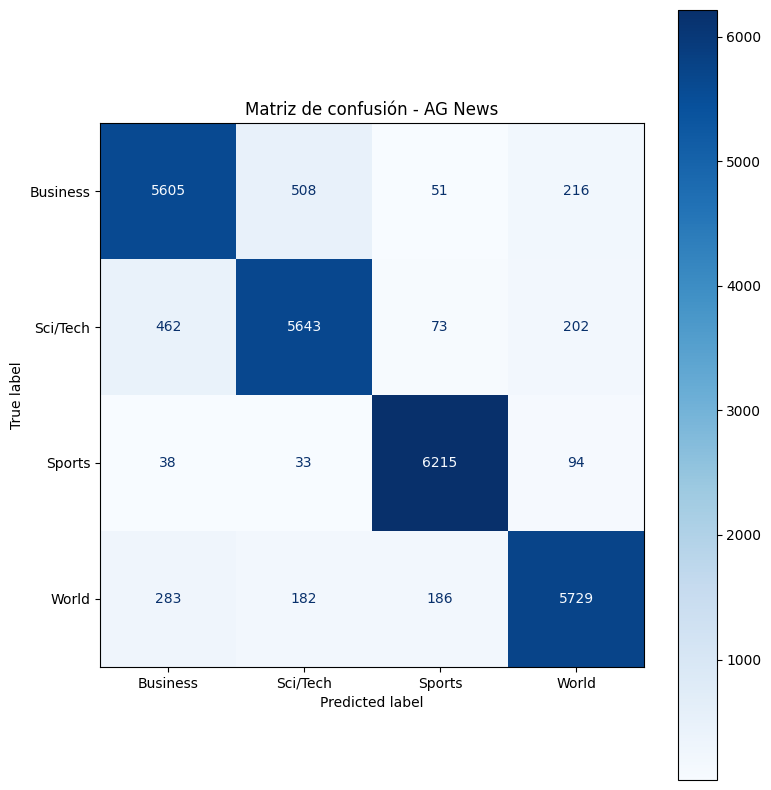

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title("Matriz de confusión - AG News")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/confusion_matrix_ag_news.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Ejemplos de predicción

In [12]:
examples = pd.DataFrame({
    "texto": X_test.iloc[:10].values,
    "real": y_test.iloc[:10].values,
    "prediccion": y_pred[:10]
})

examples

,texto,real,prediccion
0,court reject challenge list washington reuters...,Business,Business
1,broadhurst fichardt open de madrid madrid spai...,Sports,Sports
2,win convince fine lt gt lt gt mouth water pros...,Sports,Sports
3,new check law sink check float practice practi...,Business,Business
4,weekend tv radio today auto racing nascar busc...,Sports,Sports
5,don regulate rfid industry deserve chance act ...,Sci/Tech,Sci/Tech
6,enter mail time speculate month ago sony annou...,Sci/Tech,Sci/Tech
7,nesterenko belarus win woman olympic gold bela...,Sports,Sports
8,telekom lift forecast net rise deutsche teleko...,Business,Business
9,suicide car bomb kill pakistan religious rally...,World,World


Guardado de métricas y reporte de clasificación

In [13]:
import json

metrics_path = "../outputs/reports/metrics_ag_news.json"
report_path = "../outputs/reports/classification_report_ag_news.csv"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

report_df.to_csv(report_path)

print(f"Métricas guardadas en: {metrics_path}")
print(f"Reporte de clasificación guardado en: {report_path}")

Métricas guardadas en: ../outputs/reports/metrics_ag_news.json
Reporte de clasificación guardado en: ../outputs/reports/classification_report_ag_news.csv


Guardado del modelo entrenado

In [14]:
import joblib

model_artifacts = {
    "tfidf_vectorizer": tfidf,
    "model": model,
    "classes": model.classes_
}

model_path = "../models/ag_news_tfidf_logistic_regression_model.pkl"

joblib.dump(model_artifacts, model_path)

print(f"Modelo guardado en: {model_path}")

Modelo guardado en: ../models/ag_news_tfidf_logistic_regression_model.pkl


Interpretabilidad del modelo mediante términos relevantes

In [15]:
feature_names = tfidf.get_feature_names_out()

for idx, class_name in enumerate(model.classes_):
    top_features = sorted(
        zip(model.coef_[idx], feature_names),
        reverse=True
    )[:10]

    print("\n")
    print("=" * 60)
    print(class_name)
    print("=" * 60)

    for score, word in top_features:
        print(f"{word}: {score:.4f}")



Business
retailer: 4.4961
economy: 4.3309
hellip: 4.0967
oil: 3.9148
tax: 3.6965
economic: 3.6796
bank: 3.6338
martha: 3.5654
company: 3.5601
quickinfo: 3.5105


Sci/Tech
nasa: 5.8134
internet: 5.2093
space: 5.1738
scientist: 4.9244
software: 4.4905
technology: 3.9852
web: 3.9528
apple: 3.9207
microsoft: 3.8135
online: 3.8010


Sports
coach: 6.1247
cup: 5.8357
team: 4.9626
player: 4.5317
stadium: 4.5076
sport: 4.4978
champion: 4.3589
olympic: 4.3544
league: 4.2511
nba: 4.0919


World
afp: 7.0494
iraq: 5.1745
iraqi: 4.4008
hostage: 4.3001
arafat: 4.1588
nuclear: 4.1188
un: 3.9879
leader: 3.9257
press: 3.5917
palestinian: 3.5520
